# Finite-Elemente-Methode in 1D

Dieses Notebook erklärt eine vollständige 1D-FEM-Implementierung Zeile für Zeile, mit Bezug zur mathematischen Theorie der Galerkin-Methode.

## Die Aufgabe

Wir lösen die eindimensionale Randwertaufgabe:

$$-\frac{d}{dx}\left(\alpha(x)\,\frac{d\Phi}{dx}\right) + \beta(x)\,\Phi(x) = f(x), \quad x\in [a,b]$$

mit Dirichlet-Randbedingungen $\Phi(a) = \Phi_a$ und $\Phi(b) = \Phi_b$.

**Konkretes Beispiel aus dem Skript:**
$$-\frac{d}{dx}\left(x^2\,\frac{d\Phi}{dx}\right) + x\,\Phi = -x^3, \quad \Phi(1)=2,\ \Phi(2)=6$$

## Übersicht

1. **Schwache Form** durch Multiplikation mit Testfunktion und partielle Integration
2. **Diskretisierung** mit linearen Hutfunktionen (Lagrange-Elemente P1)
3. **Galerkin-Ansatz**: Test- und Basisfunktionen identisch wählen
4. **Element-für-Element-Assembly** der lokalen 2×2-Matrizen in die globale Matrix
5. **Randbedingungen** einbauen (Dirichlet durch Streichen, Robin durch Modifikation)
6. **Lineares Gleichungssystem** $\mathbf{K}\mathbf{a} = \mathbf{D}$ lösen

---
## 1. Imports und mathematischer Hintergrund

Wir benötigen:
- **NumPy** für die lineare Algebra (Matrizen, Vektoren, Solver)
- **Matplotlib** für die Visualisierung der Lösung
- **SciPy.sparse** für später, wenn wir mit großen Matrizen arbeiten (Sparse-Speicherung)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse

---
## 2. Mesh-Definition

Das **Mesh** ist die diskrete Beschreibung unserer Geometrie. In 1D besteht es aus:
- **Knoten** (Punkte auf dem Intervall)
- **Elementen** (Teilintervalle zwischen benachbarten Knoten)

Wir verwenden zwei Datenstrukturen:

**`p`-Liste** (Points): Knotenkoordinaten. Der Index ist die **globale Knotennummer**, der Wert die räumliche Position.

$$p[i] = x_i \quad \text{(Position des Knotens } i\text{)}$$

**`t`-Liste** (Topology): Element-Konnektivität. Jeder Eintrag enthält die zwei globalen Knotennummern des Elements.

$$t[e] = [g_1, g_2] \quad \text{(globale Knotennummern des Elements } e\text{)}$$

**Hinweis:** Die Knotennummerierung muss nicht räumlich aufsteigend sein — das simuliert die Situation in 2D/3D, wo Mesh-Generatoren chaotische Nummerierungen liefern. Die `t`-Liste wird hier mit `np.argsort` automatisch erzeugt, sodass jedes Element zwei räumlich benachbarte Knoten verbindet.

In [2]:
# Knotenkoordinaten (chaotische Nummerierung als Vorübung für 2D)
p = [1.75, 2.0, 1.25, 1.0, 1.5]

# Element-Konnektivität automatisch erzeugen:
# np.argsort(p) liefert die Knotenindizes in räumlich aufsteigender Reihenfolge
# Jedes Element verbindet dann zwei räumlich benachbarte Knoten
t = [[np.argsort(p)[i], np.argsort(p)[i+1]] for i in range(len(p)-1)]

print("Knotenkoordinaten p:", p)
print("Räumliche Sortierung argsort(p):", np.argsort(p).tolist())
print("Element-Liste t:", t)
print(f"Anzahl Knoten: {len(p)}, Anzahl Elemente: {len(t)}")

Knotenkoordinaten p: [1.75, 2.0, 1.25, 1.0, 1.5]
Räumliche Sortierung argsort(p): [3, 2, 4, 0, 1]
Element-Liste t: [[np.int64(3), np.int64(2)], [np.int64(2), np.int64(4)], [np.int64(4), np.int64(0)], [np.int64(0), np.int64(1)]]
Anzahl Knoten: 5, Anzahl Elemente: 4


---
## 3. Materialfunktionen und Quellterm

Die DGL enthält drei gegebene Funktionen, die das physikalische Problem beschreiben:

| Symbol | Bedeutung | Elektrostatische Interpretation |
|--------|-----------|--------------------------------|
| $\alpha(x)$ | Diffusionskoeffizient | Permittivität $\varepsilon(x)$ [As/Vm] |
| $\beta(x)$ | Reaktionskoeffizient | 0 in reiner Elektrostatik |
| $f(x)$ | Quellterm | Raumladungsdichte $\rho(x)$ [As/m³] |

Zusätzlich für **Robin-Randbedingungen** der Form $\alpha\,\frac{d\Phi}{dn} + \gamma\,\Phi = q$:

| Symbol | Bedeutung |
|--------|-----------|
| $\gamma(x)$ | Robin-Koeffizient |
| $q(x)$ | Randwert (z.B. Oberflächenladungsdichte) |

Wir definieren die Funktionen folgendermaßen:

$$\alpha(x) = x^2, \qquad \beta(x) = x, \qquad f(x) = -x^3$$

In [3]:
def alpha(x): return x**2     # Diffusionskoeffizient / Permittivität
def beta(x):  return x         # Reaktionskoeffizient
def f(x):     return -x**3     # Quellterm / Ladungsdichte
def q(x):     return 0         # Robin-Randwert (hier nicht aktiv)
def gamma(x): return 0         # Robin-Koeffizient (hier nicht aktiv)

---
## Schritt 4: Randbedingungen

**Dirichlet-Randbedingungen** schreiben den Wert von $\Phi$ an bestimmten Knoten fest:
$$\Phi(x_d) = \Phi_d \quad \text{für } d \in d_R$$

Diese Werte sind **bekannt** und müssen nicht berechnet werden. Sie wandern später auf die rechte Seite des Gleichungssystems.

**Robin-Randbedingungen** koppeln Wert und Normalableitung von $\Phi$:
$$\alpha\,\frac{d\Phi}{dn} + \gamma\,\Phi = q \quad \text{auf } \Gamma_R$$

Zunächst werden nur die Dirichlet Randbedingungen berücksichtigt.

Aus der ursprünglichen DGL mit $\Phi(1) = 2$ und $\Phi(2) = 6$:
- Knoten mit $x = 1.0$ hat globale Nummer **3** → $\Phi_3 = 2$
- Knoten mit $x = 2.0$ hat globale Nummer **1** → $\Phi_1 = 6$

In [ ]:
# (globalen) Dirichlet-Randknoten und ihre vorgeschriebenen Werte
dR   = [3, 1]
PhiR = [2.0, 6.0]

# Robin-Randknoten (in diesem Beispiel keine)
rR = []

# Kontrollausgabe
for d, phi in zip(dR, PhiR):
    print(f"Knoten {d} (bei x={p[d]}): Phi = {phi}")

Knoten 3 (bei x=1.0): Phi = 2.0
Knoten 1 (bei x=2.0): Phi = 6.0


---
## 5. Theorie — Die schwache Form und der Galerkin-Ansatz

### 5.1 Schwache Form

Wir multiplizieren die DGL mit einer **Testfunktion** $v(x)$ und integrieren über das Gebiet:

$$\int_a^b v\left[-\frac{d}{dx}\left(\alpha\,\frac{d\Phi}{dx}\right) + \beta\,\Phi\right]dx = \int_a^b v\,f\,dx$$

Mit **partieller Integration** des ersten Terms entsteht:

$$\int_a^b \alpha\,\frac{dv}{dx}\,\frac{d\Phi}{dx}\,dx - \left[v\,\alpha\,\frac{d\Phi}{dx}\right]_a^b + \int_a^b \beta\,v\,\Phi\,dx = \int_a^b v\,f\,dx$$

Vorteile dieser Form:
- Nur **erste** Ableitungen — geringere Glattheitsanforderung
- **Randterm** als Tor für Robin-Randbedingungen
- **Symmetrie** in $v$ und $\Phi$ (Hauptterm)

### 5.2 Galerkin-Ansatz mit Hutfunktionen

Wir approximieren die Lösung als Linearkombination von Basisfunktionen $U_j$:

$$\tilde\Phi(x) = \sum_{j=1}^N \Phi_j\,U_j(x)$$

Bei **Galerkin** wählen wir **Test- und Basisfunktionen identisch**: $v = U_k$.

Wir verwenden **lineare Hutfunktionen** (auch P1-Elemente genannt). Eine Hutfunktion $U_k$ hat:
- Wert 1 am eigenen Knoten $x_k$
- Wert 0 an allen anderen Knoten
- Stückweise lineare Verbindung dazwischen
- **Kompakter Träger**: nur auf den zwei angrenzenden Elementen ungleich null

Daraus folgt die wichtigste Eigenschaft: $\Phi_j = \tilde\Phi(x_j)$ — **die Koeffizienten sind direkt die Knotenwerte**.

### 5.3 Lineares Gleichungssystem

Einsetzen in die schwache Form ergibt das LGS:

$$\mathbf{K}\,\boldsymbol{\Phi} = \mathbf{D}$$

mit der **Steifigkeitsmatrix**

$$K_{kj} = \int_a^b \alpha\,U_k'\,U_j'\,dx + \int_a^b \beta\,U_k\,U_j\,dx$$

und dem **Lastvektor**

$$D_k = \int_a^b U_k\,f\,dx$$

---
## Schritt 6: Theorie — Lokale Element-Matrix

Statt die globalen Integrale direkt zu berechnen, gehen wir **elementweise** vor. Auf jedem Element $E_e$ mit Knoten $x_1$ und $x_2$ leben nur **zwei** Hutfunktionen, die wir lokal als $N_1, N_2$ bezeichnen:

$$N_1(x) = \frac{x_2 - x}{L_E}, \qquad N_2(x) = \frac{x - x_1}{L_E}$$

mit Elementlänge $L_E = x_2 - x_1$. Die Ableitungen sind konstant:

$$N_1' = -\frac{1}{L_E}, \qquad N_2' = +\frac{1}{L_E}$$

Daraus ergibt sich für jedes Element eine **2×2-Matrix** und ein **2×1-Lastvektor**.

### 6.1 Die vier Integrale pro Element

Mit der Mittelpunktsregel-Approximation $\alpha(x) \approx \alpha(x_M)$ und $\beta(x) \approx \beta(x_M)$ ergibt sich:

**Diagonalelemente** ($l = m$):
$$\mathcal{K}_{11} = \mathcal{K}_{22} = \underbrace{\frac{\alpha(x_M)}{L_E}}_{\text{Steifigkeit}} + \underbrace{\frac{L_E\,\beta(x_M)}{3}}_{\text{Masse}}$$

**Außerdiagonale** ($l \neq m$):
$$\mathcal{K}_{12} = \mathcal{K}_{21} = \underbrace{-\frac{\alpha(x_M)}{L_E}}_{\text{Steifigkeit}} + \underbrace{\frac{L_E\,\beta(x_M)}{6}}_{\text{Masse}}$$

### 6.2 Der Lastvektor

$$\mathcal{D}_1 = \mathcal{D}_2 = \frac{L_E\,f(x_M)}{2}$$

Die Quelle wird gleichmäßig auf die beiden Knoten des Elements verteilt.

### 6.3 Physikalische Interpretation (elektrostatisch)

Mit $\alpha = \varepsilon$ und $\beta = 0$:
- **Diagonale** $\mathcal{K}_{11} = \varepsilon/L_E$: entspricht der Kapazität eines Plattenkondensators $C = \varepsilon A/d$ in 1D-Form
- **Außerdiagonale** $\mathcal{K}_{12} = -\varepsilon/L_E$: Koppelkapazität zwischen den Knoten

---
## 7. Initialisierung der globalen Datenstrukturen

In [5]:
# Anzahl der Knoten = Größe der globalen Matrix
N = len(p)

# Globale Steifigkeitsmatrix (N×N) und Lastvektor (N×1), initial alles null
K = np.zeros((N, N))
D = np.zeros(N)

print(f"Globale Matrix K hat Dimension {K.shape}")
print(f"Lastvektor D hat Dimension {D.shape}")

Globale Matrix K hat Dimension (5, 5)
Lastvektor D hat Dimension (5,)


---
## 8. Element-Loop und Assembly

Das **Herzstück** der FEM. Für jedes Element:

1. Globale Knotennummern $g_1, g_2$ und Koordinaten $x_1, x_2$ holen
2. Elementlänge $L_E$ und Mittelpunkt $x_M$ berechnen
3. Materialfunktionen an $x_M$ auswerten
4. Lokale 2×2-Matrix und 2×1-Lastvektor berechnen
5. **Einsortieren** in die globale Matrix mit `+=` (Akkumulation!)

### Wichtig: Lokal-zu-global-Übersetzung

Der lokale Index 1 entspricht dem globalen Knoten $g_1$, der lokale Index 2 entspricht $g_2$. Die `t`-Liste ist die Übersetzungstabelle:

| Lokaler Index | Globaler Index |
|---|---|
| 1 (links) | $g_1 = t[e][0]$ |
| 2 (rechts) | $g_2 = t[e][1]$ |

### Akkumulation: Warum `+=` wichtig ist

Ein **innerer Knoten** gehört zu **zwei** Elementen (links und rechts davon). Sein Diagonaleintrag in der globalen Matrix bekommt also **zwei Beiträge**, einen aus jedem Element. Das `+=` (Addition statt Zuweisung) sorgt dafür, dass beide Beiträge aufsummiert werden, statt einer den anderen zu überschreiben.

In [6]:
for i in range(len(t)):
    # --- Globale Knotennummern dieses Elements ---
    g1, g2 = t[i][0], t[i][1]
    
    # --- Räumliche Koordinaten der Knoten ---
    x1, x2 = p[g1], p[g2]
    
    # --- Lokale Konvention: x1 < x2 (links < rechts) ---
    if x1 > x2:
        x1, x2 = x2, x1
        g1, g2 = g2, g1
    
    # --- Elementgrößen ---
    L_E = x2 - x1         # Elementlänge
    xM  = (x1 + x2) / 2   # Mittelpunkt für Quadratur
    
    # --- Materialfunktionen am Mittelpunkt auswerten ---
    aM = alpha(xM)
    bM = beta(xM)
    fM = f(xM)
    
    # --- Lokale 2×2-Matrix berechnen ---
    # Diagonale:   K_diag = α(xM)/L_E + L_E*β(xM)/3
    # Außerdiagonale: K_off = -α(xM)/L_E + L_E*β(xM)/6
    K_diag    = aM / L_E + bM * L_E / 3
    K_offdiag = -aM / L_E + bM * L_E / 6
    
    K_local = np.array([[K_diag,    K_offdiag],
                        [K_offdiag, K_diag]])
    
    # --- Lokaler Lastvektor: gleichmäßige Verteilung der Quelle ---
    D_local = np.array([fM * L_E / 2,
                        fM * L_E / 2])
    
    # --- Assembly: lokale Beiträge in globale Matrix einsortieren ---
    # Lokaler Knoten 1 → globaler Knoten g1
    # Lokaler Knoten 2 → globaler Knoten g2
    K[g1, g1] += K_local[0, 0]
    K[g1, g2] += K_local[0, 1]
    K[g2, g1] += K_local[1, 0]
    K[g2, g2] += K_local[1, 1]
    
    D[g1] += D_local[0]
    D[g2] += D_local[1]

print("Globale Steifigkeitsmatrix K nach Assembly:")
print(np.round(K, 4))
print("\nGlobaler Lastvektor D nach Assembly:")
print(np.round(D, 4))

Globale Steifigkeitsmatrix K nach Assembly:
[[ 24.9167 -13.9844   0.       0.     -10.4948]
 [-13.9844  14.2188   0.       0.       0.    ]
 [  0.       0.      12.8333  -5.0156  -7.5052]
 [  0.       0.      -5.0156   5.1562   0.    ]
 [-10.4948   0.      -7.5052   0.      18.375 ]]

Globaler Lastvektor D nach Assembly:
[-1.3604 -0.824  -0.5029 -0.178  -0.8613]


**Beobachtung zur Matrixstruktur:**

Die Matrix ist **dünn besetzt** — nur die Diagonale und die zwei Nachbar-Diagonalen sind ungleich null. Das liegt am kompakten Träger der Hutfunktionen: $K_{kj} \neq 0$ nur wenn $|k - j| \leq 1$ in räumlicher Sortierung.

**Wegen der chaotischen Nummerierung** ist die Bandstruktur nicht offensichtlich (z.B. ist $K_{0,4}$ ungleich null, weil die Knoten 0 und 4 räumlich benachbart sind). In einem sortierten Mesh wäre die Matrix tridiagonal.

---
## Schritt 9: Robin-Randbedingungen einbauen

Bei Robin-Randbedingungen $\alpha\,\frac{d\Phi}{dn} + \gamma\,\Phi = q$ entsteht aus dem Randterm der schwachen Form ein zusätzlicher Beitrag.

Für jeden Robin-Knoten $r$:
- $\gamma$ wird zum **Diagonaleintrag** $K_{rr}$ addiert
- $q$ wird zum **Lastvektor** $D_r$ addiert

$$K_{rr} \leftarrow K_{rr} + \gamma(x_r)$$
$$D_r \leftarrow D_r + q(x_r)$$

**Im aktuellen Beispiel** ist `rR = []` (keine Robin-Knoten), daher hat dieser Schritt keine Wirkung.

In [7]:
for r in rR:
    x_r = p[r]
    K[r, r] += gamma(x_r)
    D[r]    += q(x_r)

print(f"Robin-Randbedingungen: {len(rR)} Knoten betroffen (im Beispiel keine)")

Robin-Randbedingungen: 0 Knoten betroffen (im Beispiel keine)


---
## Schritt 10: Dirichlet-Randbedingungen einbauen

Bei Dirichlet-Knoten sind die Werte $\Phi_d$ **bekannt** und sollen nicht im LGS gelöst werden. Die Strategie:

**10a.** Die bekannten Beiträge werden aus dem LGS herausgenommen, indem sie **auf die rechte Seite** verschoben werden:
$$\mathbf{D} \leftarrow \mathbf{D} - \Phi_d\cdot \mathbf{K}_{:,d}$$
wobei $\mathbf{K}_{:,d}$ die $d$-te **Spalte** der Matrix ist.

**10b.** Anschließend werden die Zeilen und Spalten der Dirichlet-Knoten aus dem System **gestrichen**, sodass nur noch die unbekannten Werte an inneren Knoten übrig bleiben.

### Warum funktioniert das?

Die volle Galerkin-Gleichung für eine innere Knoten-Gleichung $k$ lautet:
$$\sum_{j=1}^{N} K_{kj}\,\Phi_j = D_k$$

Wenn $\Phi_d$ bekannt ist, können wir den Term $K_{kd}\,\Phi_d$ aus der Summe nehmen und auf die rechte Seite ziehen:
$$\sum_{j \neq d} K_{kj}\,\Phi_j = D_k - K_{kd}\,\Phi_d$$

Das ergibt ein kleineres LGS für nur die unbekannten $\Phi_j$.

In [8]:
# Schritt 10a: Bekannte Beiträge auf die rechte Seite ziehen
for d, phi_d in zip(dR, PhiR):
    D = D - phi_d * K[:, d]

# Schritt 10b: Reduziertes System aufstellen (nur innere Knoten)
inner_nodes = [i for i in range(N) if i not in dR]
K_reduced = K[np.ix_(inner_nodes, inner_nodes)]
D_reduced = D[inner_nodes]

print(f"Innere Knoten (unbekannte Werte): {inner_nodes}")
print(f"\nReduzierte Matrix K_reduced ({K_reduced.shape}):")
print(np.round(K_reduced, 4))
print(f"\nReduzierter Lastvektor D_reduced:")
print(np.round(D_reduced, 4))

Innere Knoten (unbekannte Werte): [0, 2, 4]

Reduzierte Matrix K_reduced ((3, 3)):
[[ 24.9167   0.     -10.4948]
 [  0.      12.8333  -7.5052]
 [-10.4948  -7.5052  18.375 ]]

Reduzierter Lastvektor D_reduced:
[82.5459  9.5283 -0.8613]


---
## Schritt 11: Lösen des linearen Gleichungssystems

Jetzt lösen wir das reduzierte System:
$$\mathbf{K}_{\text{red}}\,\boldsymbol{\Phi}_{\text{innen}} = \mathbf{D}_{\text{red}}$$

Für kleine Probleme verwenden wir `np.linalg.solve`. Bei großen Systemen würde man `scipy.sparse.linalg.spsolve` oder iterative Solver wie Konjugierte Gradienten verwenden, die die Sparsity-Struktur ausnutzen.

### Mathematischer Hintergrund

Das System ist **symmetrisch positiv definit** (weil Galerkin mit selbstadjungiertem Operator). Daher ist die Lösung **eindeutig** und alle Eigenwerte sind positiv reell — sehr gute numerische Eigenschaften.

In [9]:
# LGS lösen
Phi_inner = np.linalg.solve(K_reduced, D_reduced)

print("Berechnete Werte an inneren Knoten:")
for i, node in enumerate(inner_nodes):
    print(f"  Knoten {node} (x = {p[node]}): Phi = {Phi_inner[i]:.6f}")

Berechnete Werte an inneren Knoten:
  Knoten 0 (x = 1.75): Phi = 5.051262
  Knoten 2 (x = 1.25): Phi = 3.156176
  Knoten 4 (x = 1.5): Phi = 4.127258


---
## Schritt 12: Gesamtlösung zusammensetzen

Wir kombinieren:
- Die **berechneten Werte** an den inneren Knoten (aus dem LGS)
- Die **vorgegebenen Werte** an den Dirichlet-Randknoten

Das ergibt den vollständigen Lösungsvektor $\boldsymbol{\Phi}_{\text{komplett}}$ der Länge $N$.

In [10]:
Phi_complete = np.zeros(N)

# Innere Knotenwerte einsortieren
for i, node in enumerate(inner_nodes):
    Phi_complete[node] = Phi_inner[i]

# Dirichlet-Knotenwerte einsortieren
for d, phi_d in zip(dR, PhiR):
    Phi_complete[d] = phi_d

# Tabellarische Ausgabe der Ergebnisse
print("Knoten | x       | Phi(x)")
print("-" * 35)
for i in range(N):
    typ = "(Dirichlet)" if i in dR else ""
    print(f"{i:5d}  | {p[i]:7.3f} | {Phi_complete[i]:7.3f}  {typ}")

Knoten | x       | Phi(x)
-----------------------------------
    0  |   1.750 |   5.051  
    1  |   2.000 |   6.000  (Dirichlet)
    2  |   1.250 |   3.156  
    3  |   1.000 |   2.000  (Dirichlet)
    4  |   1.500 |   4.127  


**Vergleich mit dem Skript:** Die berechneten Werte sollten mit der Tabelle aus dem Skript übereinstimmen:

| $x$ | $\Phi(x)$ |
|---|---|
| 1.00 | 2.000 |
| 1.25 | 3.156 |
| 1.50 | 4.127 |
| 1.75 | 5.051 |
| 2.00 | 6.000 |

---
## Schritt 13: Visualisierung

Die FEM-Approximation $\tilde\Phi(x) = \sum_k \Phi_k\,U_k(x)$ ist auf jedem Element **linear**. Insgesamt ergibt sich ein **Polygonzug** durch die Knotenwerte.

Da unsere Knotennummerierung chaotisch ist, müssen wir vor dem Plotten **nach räumlicher Position sortieren**.

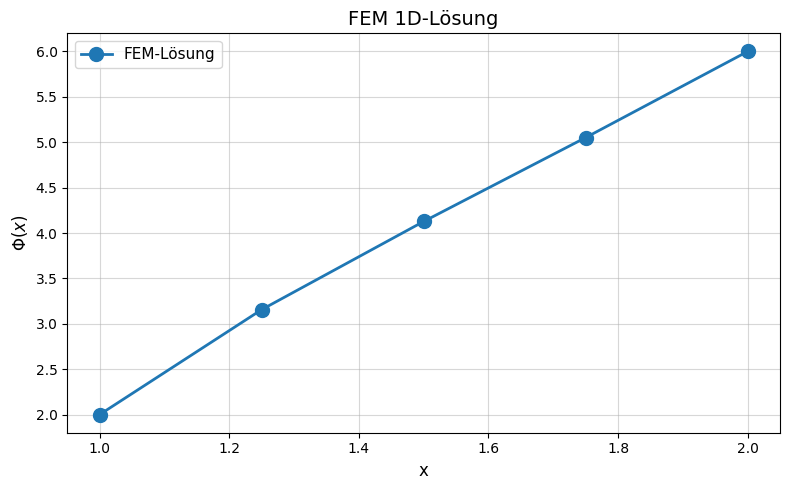

In [11]:
# Räumliche Sortierung für sauberen Plot
p_array = np.array(p)
order = np.argsort(p_array)

plt.figure(figsize=(8, 5))
plt.plot(p_array[order], Phi_complete[order], marker='o', linewidth=2,
         markersize=10, label='FEM-Lösung')
plt.xlabel('x', fontsize=12)
plt.ylabel(r'$\Phi(x)$', fontsize=12)
plt.title('FEM 1D-Lösung', fontsize=14)
plt.grid(True, alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

---
## Zusammenfassung der gesamten Methode

Die Finite-Elemente-Methode in 1D folgt einer klaren Pipeline:

1. **DGL → schwache Form** durch partielle Integration  
   Reduziert Glattheitsanforderung von $C^2$ auf $H^1$

2. **Diskretisierung mit Hutfunktionen**  
   Endlich viele Freiheitsgrade $\Phi_j$, kompakter Träger → dünne Matrix

3. **Galerkin-Ansatz** $v = U_k$  
   Test- und Basisfunktionen identisch → symmetrische Matrix

4. **Element-für-Element-Assembly**  
   Universelle Element-Routine, Akkumulation per `+=`

5. **Randbedingungen einbauen**  
   Dirichlet: streichen + auf rechte Seite ziehen  
   Robin: zur Steifigkeit und zum Lastvektor addieren

6. **LGS lösen** → Knotenwerte

7. **Lösung visualisieren** als Polygonzug

### Übergeordnete Konzepte

Die FEM-Lösung ist die **orthogonale Projektion** der echten Lösung $\Phi$ auf den Ansatzraum $V_N$ bezüglich des **Energie-Skalarprodukts**:

$$\langle u, v\rangle_E = \int \alpha\,u'\,v'\,dx + \int \beta\,u\,v\,dx$$

Die FEM minimiert daher den Fehler $\Phi - \tilde\Phi$ in der **Energienorm** $\|\cdot\|_E$. Das ist das **Céa-Lemma** und der Grund, warum die FEM die beste Approximation im Ansatzraum liefert.

Bei feinerem Mesh ($h \to 0$) konvergiert die FEM-Lösung gegen die exakte Lösung mit **quadratischer Rate**:
$$\|\Phi - \tilde\Phi\|_{L^2} \leq C\,h^2$$

Das ist die **$h$-Konvergenz** linearer FEM-Elemente.